In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load data
df = pd.read_excel("C:/Users/gomat/Downloads/Crime_Data (1).xlsx")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,5741943,HN549294,2007-08-25 09:22:18,074XX N ROGERS AVE,560,ASSAULT,SIMPLE,OTHER,False,False,...,49.0,1.0,08A,NaN,NaN,2007,2015-08-17 15:03:40,NaN,NaN,NaN
1,25953,JE240540,2021-05-24 15:06:00,020XX N LARAMIE AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,36.0,19.0,01A,1141387.0,1913179.0,2021,2023-11-18 15:39:49,41.917838,-87.755969,"(41.917838056, -87.755968972)"
2,26038,JE279849,2021-06-26 09:24:00,062XX N MC CORMICK RD,110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,50.0,13.0,01A,1152781.0,1941458.0,2021,2023-11-18 15:39:49,41.995219,-87.713355,"(41.995219444, -87.713354912)"
3,13279676,JG507211,2023-11-09 07:30:00,019XX W BYRON ST,620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,47.0,5.0,5,1162518.0,1925906.0,2023,2023-11-18 15:39:49,41.952345,-87.677975,"(41.952345086, -87.677975059)"
4,13274752,JG501049,2023-11-12 07:59:00,086XX S COTTAGE GROVE AVE,454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,6.0,44.0,08B,1183071.0,1847869.0,2023,2023-12-09 15:41:24,41.737751,-87.604856,"(41.737750767, -87.604855911)"


In [16]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location', 'Hour', 'Time of Day'],
      dtype='object')

In [17]:
# data cleaning 
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Primary Type', 'Location Description', 'Date', 'Latitude', 'Longitude'])
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Hour,Time of Day
1,25953,JE240540,2021-05-24 15:06:00,020XX N LARAMIE AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,01A,1141387.0,1913179.0,2021,2023-11-18 15:39:49,41.917838,-87.755969,"(41.917838056, -87.755968972)",15,Afternoon
2,26038,JE279849,2021-06-26 09:24:00,062XX N MC CORMICK RD,110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,01A,1152781.0,1941458.0,2021,2023-11-18 15:39:49,41.995219,-87.713355,"(41.995219444, -87.713354912)",9,Morning
3,13279676,JG507211,2023-11-09 07:30:00,019XX W BYRON ST,620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,5,1162518.0,1925906.0,2023,2023-11-18 15:39:49,41.952345,-87.677975,"(41.952345086, -87.677975059)",7,Morning
4,13274752,JG501049,2023-11-12 07:59:00,086XX S COTTAGE GROVE AVE,454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,08B,1183071.0,1847869.0,2023,2023-12-09 15:41:24,41.737751,-87.604856,"(41.737750767, -87.604855911)",7,Morning
6,13203321,JG415333,2023-09-06 17:00:00,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,14,1174694.0,1901831.0,2023,2023-11-04 15:40:18,41.886018,-87.633938,"(41.886018055, -87.633937881)",17,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549994,1715153,G516233,2001-08-27 23:00:00,036XX S LAKE PARK AV,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE,False,True,...,26,1182305.0,1881212.0,2001,2015-08-17 15:03:40,41.829265,-87.606630,"(41.829264761, -87.606629868)",23,Night
549995,1799889,G625392,2001-10-16 16:30:00,065XX S STEWART AV,610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,...,5,1174713.0,1861451.0,2001,2015-08-17 15:03:40,41.775211,-87.635073,"(41.775211478, -87.635073388)",16,Afternoon
549996,1769834,G583569,2001-09-29 05:35:00,031XX N CENTRAL PARK AV,460,BATTERY,SIMPLE,RESIDENCE,False,True,...,08B,1151878.0,1920763.0,2001,2015-08-17 15:03:40,41.938449,-87.717224,"(41.938448908, -87.717224032)",5,Morning
549997,1788327,G610965,2001-09-12 09:05:00,065XX S CICERO AV,910,MOTOR VEHICLE THEFT,AUTOMOBILE,OTHER,True,False,...,7,1145544.0,1861043.0,2001,2015-08-17 15:03:40,41.774692,-87.742015,"(41.774692006, -87.742014699)",9,Morning


In [18]:
# Extract date features
df['Year'] = df['Date'].dt.year
df['Hour'] = df['Date'].dt.hour
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Hour,Time of Day
1,25953,JE240540,2021-05-24 15:06:00,020XX N LARAMIE AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,01A,1141387.0,1913179.0,2021,2023-11-18 15:39:49,41.917838,-87.755969,"(41.917838056, -87.755968972)",15,Afternoon
2,26038,JE279849,2021-06-26 09:24:00,062XX N MC CORMICK RD,110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,01A,1152781.0,1941458.0,2021,2023-11-18 15:39:49,41.995219,-87.713355,"(41.995219444, -87.713354912)",9,Morning
3,13279676,JG507211,2023-11-09 07:30:00,019XX W BYRON ST,620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,5,1162518.0,1925906.0,2023,2023-11-18 15:39:49,41.952345,-87.677975,"(41.952345086, -87.677975059)",7,Morning
4,13274752,JG501049,2023-11-12 07:59:00,086XX S COTTAGE GROVE AVE,454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,08B,1183071.0,1847869.0,2023,2023-12-09 15:41:24,41.737751,-87.604856,"(41.737750767, -87.604855911)",7,Morning
6,13203321,JG415333,2023-09-06 17:00:00,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,14,1174694.0,1901831.0,2023,2023-11-04 15:40:18,41.886018,-87.633938,"(41.886018055, -87.633937881)",17,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549994,1715153,G516233,2001-08-27 23:00:00,036XX S LAKE PARK AV,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE,False,True,...,26,1182305.0,1881212.0,2001,2015-08-17 15:03:40,41.829265,-87.606630,"(41.829264761, -87.606629868)",23,Night
549995,1799889,G625392,2001-10-16 16:30:00,065XX S STEWART AV,610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,...,5,1174713.0,1861451.0,2001,2015-08-17 15:03:40,41.775211,-87.635073,"(41.775211478, -87.635073388)",16,Afternoon
549996,1769834,G583569,2001-09-29 05:35:00,031XX N CENTRAL PARK AV,460,BATTERY,SIMPLE,RESIDENCE,False,True,...,08B,1151878.0,1920763.0,2001,2015-08-17 15:03:40,41.938449,-87.717224,"(41.938448908, -87.717224032)",5,Morning
549997,1788327,G610965,2001-09-12 09:05:00,065XX S CICERO AV,910,MOTOR VEHICLE THEFT,AUTOMOBILE,OTHER,True,False,...,7,1145544.0,1861043.0,2001,2015-08-17 15:03:40,41.774692,-87.742015,"(41.774692006, -87.742014699)",9,Morning


In [19]:
# Time of Day category
def time_bucket(h): return (
    "Morning" if 5 <= h < 12 else
    "Afternoon" if 12 <= h < 17 else
    "Evening" if 17 <= h < 21 else
    "Night"
)
df['Time of Day'] = df['Hour'].apply(time_bucket)
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Hour,Time of Day
1,25953,JE240540,2021-05-24 15:06:00,020XX N LARAMIE AVE,110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,01A,1141387.0,1913179.0,2021,2023-11-18 15:39:49,41.917838,-87.755969,"(41.917838056, -87.755968972)",15,Afternoon
2,26038,JE279849,2021-06-26 09:24:00,062XX N MC CORMICK RD,110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,01A,1152781.0,1941458.0,2021,2023-11-18 15:39:49,41.995219,-87.713355,"(41.995219444, -87.713354912)",9,Morning
3,13279676,JG507211,2023-11-09 07:30:00,019XX W BYRON ST,620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,5,1162518.0,1925906.0,2023,2023-11-18 15:39:49,41.952345,-87.677975,"(41.952345086, -87.677975059)",7,Morning
4,13274752,JG501049,2023-11-12 07:59:00,086XX S COTTAGE GROVE AVE,454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,08B,1183071.0,1847869.0,2023,2023-12-09 15:41:24,41.737751,-87.604856,"(41.737750767, -87.604855911)",7,Morning
6,13203321,JG415333,2023-09-06 17:00:00,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,14,1174694.0,1901831.0,2023,2023-11-04 15:40:18,41.886018,-87.633938,"(41.886018055, -87.633937881)",17,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549994,1715153,G516233,2001-08-27 23:00:00,036XX S LAKE PARK AV,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE,False,True,...,26,1182305.0,1881212.0,2001,2015-08-17 15:03:40,41.829265,-87.606630,"(41.829264761, -87.606629868)",23,Night
549995,1799889,G625392,2001-10-16 16:30:00,065XX S STEWART AV,610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,...,5,1174713.0,1861451.0,2001,2015-08-17 15:03:40,41.775211,-87.635073,"(41.775211478, -87.635073388)",16,Afternoon
549996,1769834,G583569,2001-09-29 05:35:00,031XX N CENTRAL PARK AV,460,BATTERY,SIMPLE,RESIDENCE,False,True,...,08B,1151878.0,1920763.0,2001,2015-08-17 15:03:40,41.938449,-87.717224,"(41.938448908, -87.717224032)",5,Morning
549997,1788327,G610965,2001-09-12 09:05:00,065XX S CICERO AV,910,MOTOR VEHICLE THEFT,AUTOMOBILE,OTHER,True,False,...,7,1145544.0,1861043.0,2001,2015-08-17 15:03:40,41.774692,-87.742015,"(41.774692006, -87.742014699)",9,Morning


In [9]:
df['Hour'] = df['Date'].dt.hour

C:\Users\gomat\AppData\Local\Temp\ipykernel_35896\2566315363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Year', palette='coolwarm')


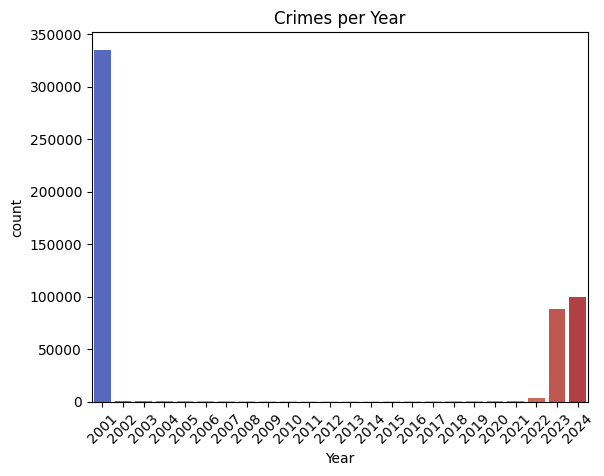

In [22]:
# Crimes per Year
sns.countplot(data=df, x='Year', palette='coolwarm')
plt.title("Crimes per Year")
plt.xticks(rotation=45)
plt.show()

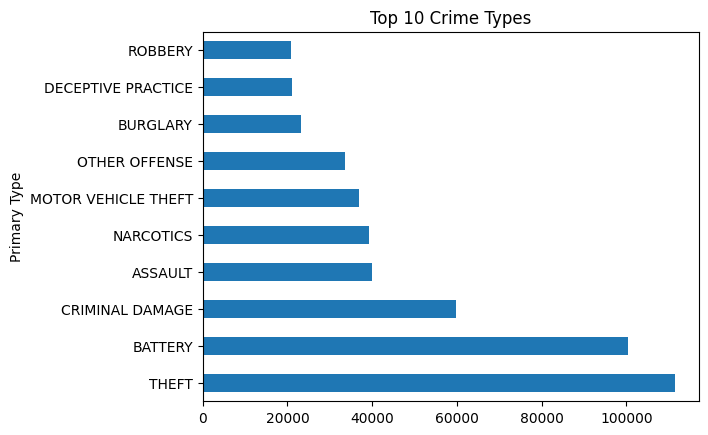

In [12]:
# Top 10 Crime Types
df['Primary Type'].value_counts().nlargest(10).plot(kind='barh')
plt.title("Top 10 Crime Types")
plt.show()

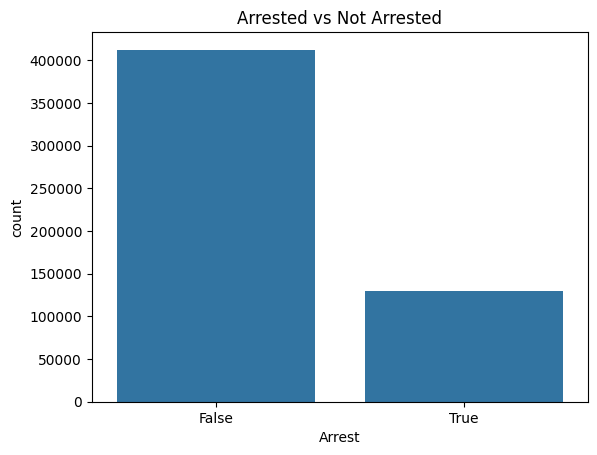

In [13]:
# Arrest Count
sns.countplot(data=df, x='Arrest')
plt.title("Arrested vs Not Arrested")
plt.show()

C:\Users\gomat\AppData\Local\Temp\ipykernel_35896\3834951062.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time of Day', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='viridis')


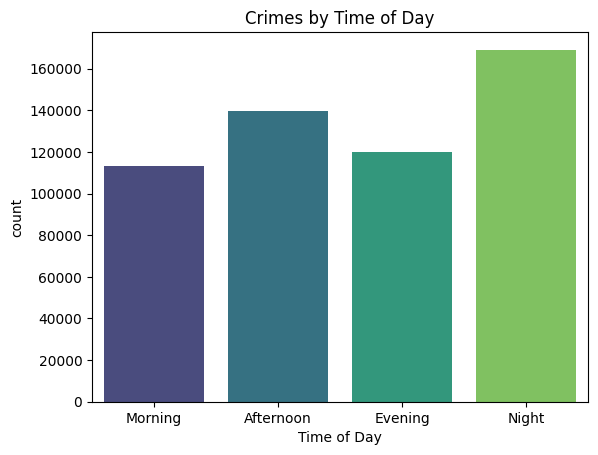

In [24]:
# crimes by time of day
sns.countplot(x='Time of Day', data=df, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='viridis')
plt.title("Crimes by Time of Day")
plt.show()

In [25]:
# Save cleaned data for Power BI
df.to_csv("Cleaned_Crime_Data.csv", index=False)